# Exploratory Data Analysis

## Loading the dataset

In [26]:
import glob
import polars as pl
import os

In [27]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")

In [28]:
def get_labels_from_filename(filename):
    if "Benign" in filename:
        return "Benign", "Benign", False

    if "ARP_Spoofing" in filename:
        return "ARP_Spoofing", "Spoofing", True

    if "Recon" in filename:
        category = "Recon"
        if "Recon-Ping_Sweep" in filename:
            return "Ping_Sweep", category, True
        if "Recon-VulScan" in filename:
            return "VulScan", category, True
        if "Recon-OS_Scan" in filename:
            return "OS_Scan", category, True
        if "Recon-Port_Scan" in filename:
            return "Port_Scan", category, True

    if "MQTT" in filename:
        category = "MQTT"
        if "MQTT-Malformed_Data" in filename:
            return "Malformed_Data", category, True
        if "MQTT-DoS-Connect_Flood" in filename:
            return "DoS_Connect_Flood", category, True
        if "MQTT-DDoS-Publish_Flood" in filename:
            return "DDoS_Publish_Flood", category, True
        if "MQTT-DoS-Publish_Flood" in filename:
            return "DoS_Publish Flood", category, True
        if "MQTT-DDoS-Connect_Flood" in filename:
            return "DDoS_Connect_Flood", category, True

    if "TCP_IP-DoS" in filename:
        category = "DoS"
        if "TCP_IP-DoS-TCP" in filename:
            return "DoS_TCP", category, True
        if "TCP_IP-DoS-ICMP" in filename:
            return "DoS_ICMP", category, True
        if "TCP_IP-DoS-SYN" in filename:
            return "DoS_SYN", category, True
        if "TCP_IP-DoS-UDP" in filename:
            return "DoS_UDP", category, True

    if "TCP_IP-DDoS" in filename:
        category = "DDoS"
        if "TCP_IP-DDoS-SYN" in filename:
            return "DDoS_SYN", category, True
        if "TCP_IP-DDoS-TCP" in filename:
            return "DDoS_TCP", category, True
        if "TCP_IP-DDoS-ICMP" in filename:
            return "DDoS_ICMP", category, True
        if "TCP_IP-DDoS-UDP" in filename:
            return "DDoS_UDP", category, True

    return "", "", False

In [29]:
def combine_dataset_files(root, save_name="combined_dataset"):
    path = os.path.join(root, "*", "*.csv")
    files = glob.glob(path, recursive=True)
    combined_dir = os.path.join(root, "combined")
    out_path = os.path.join(combined_dir, f"{save_name}.parquet")
    os.makedirs(combined_dir, exist_ok=True)

    frames = []
    with pl.StringCache():
        for file in files:
            name, category, attack = get_labels_from_filename(file)

            lf = pl.scan_csv(file)

            lf = lf.with_columns(
                [
                    pl.lit(name).alias("Name").cast(pl.Categorical),
                    pl.lit(category).alias("Category").cast(pl.Categorical),
                    pl.lit(attack).alias("Attack"),
                ]
            )

            frames.append(lf)

        combined_lf = pl.concat(frames)
        combined_lf.sink_parquet(out_path)

In [30]:
def load_dataset(save_name: str) -> pl.DataFrame:
    path = os.path.join(DATA_DIR, "combined", f"{save_name}.parquet")
    if not os.path.exists(path):
        combine_dataset_files(DATA_DIR, save_name)
    df = pl.read_parquet(path)
    return df

In [31]:
df = load_dataset("combined_dataset").with_columns(
    pl.col(pl.Float64).cast(pl.Float32)
)  # reducing memory usage

## Dataset Overview

In [32]:
df.head()

Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IGMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,Name,Category,Attack
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,cat,cat,bool
1347.0,17.0,64.0,286857.0625,286857.0625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,525.0,50.0,50.0,50.0,0.0,50.0,1.01614656e8,9.5,10.0,0.0,0.0,0.0,141.550003,"""DoS_UDP""","""DoS""",true
5625.0,17.0,64.0,25702.701172,25702.701172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,525.0,50.0,50.0,50.0,0.0,50.0,8.467888e7,9.5,10.0,0.0,0.0,0.0,141.550003,"""DoS_UDP""","""DoS""",true
10625.0,17.0,64.0,17907.132812,17907.132812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,525.0,50.0,50.0,50.0,0.0,50.0,8.467888e7,9.5,10.0,0.0,0.0,0.0,141.550003,"""DoS_UDP""","""DoS""",true
15625.0,17.0,64.0,18109.175781,18109.175781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,525.0,50.0,50.0,50.0,0.0,50.0,8.467888e7,9.5,10.0,0.0,0.0,0.0,141.550003,"""DoS_UDP""","""DoS""",true
20625.0,17.0,64.0,19269.09375,19269.09375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,525.0,50.0,50.0,50.0,0.0,50.0,8.467888e7,9.5,10.0,0.0,0.0,0.0,141.550003,"""DoS_UDP""","""DoS""",true


## Figures

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme(style="darkgrid", context="paper", palette="bright")

### Attack Types

In [34]:
def plot_attack_counts(data):
    attack_counts = data.group_by("Name").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Name", y="len", data=attack_counts, ax=ax)
    ax.set_title("Distribution of Attack Names (Entire Dataset)")
    ax.set_xlabel("Attack Name")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_558838/4110133150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


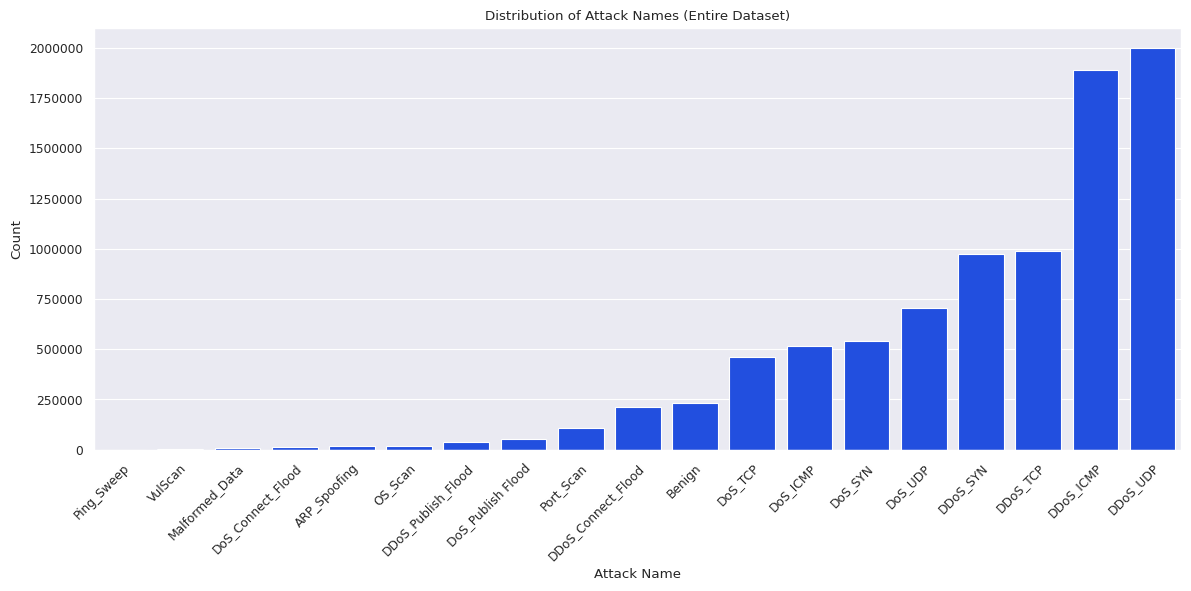

In [35]:
plot_attack_counts(df)

### DDoS vs DoS Attacks

In [36]:
def plot_ddos_dos_bar(data):
    ddos_dos_counts = (
        data.filter(pl.col("Category").is_in(["DDoS", "DoS"]))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    )
    data = ddos_dos_counts.to_pandas()
    data.columns = ["Attack Type", "Count"]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Attack Type", y="Count", data=data, ax=ax)
    ax.set_title("Distribution of DDoS and DoS Attacks (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_558838/4247166012.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


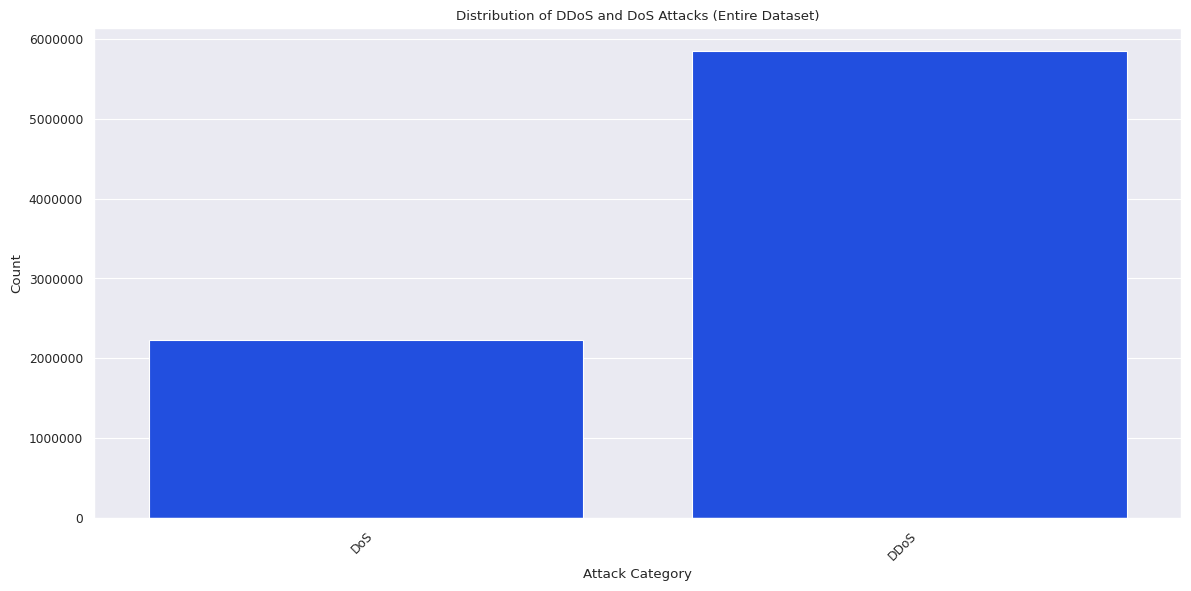

In [37]:
plot_ddos_dos_bar(df)

### Attack Categories (Exlcuding DDoS and DoS)

In [38]:
def plot_categories_no_ddos_dos(data):
    included_categories = ["MQTT", "Spoofing", "Recon", "Benign"]
    data = (
        data.filter(pl.col("Category").is_in(included_categories))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    ).to_pandas()

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title(
        "Distribution of Attack Categories (Excluding DDoS and DoS) (Entire Dataset)"
    )
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_558838/2544595696.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


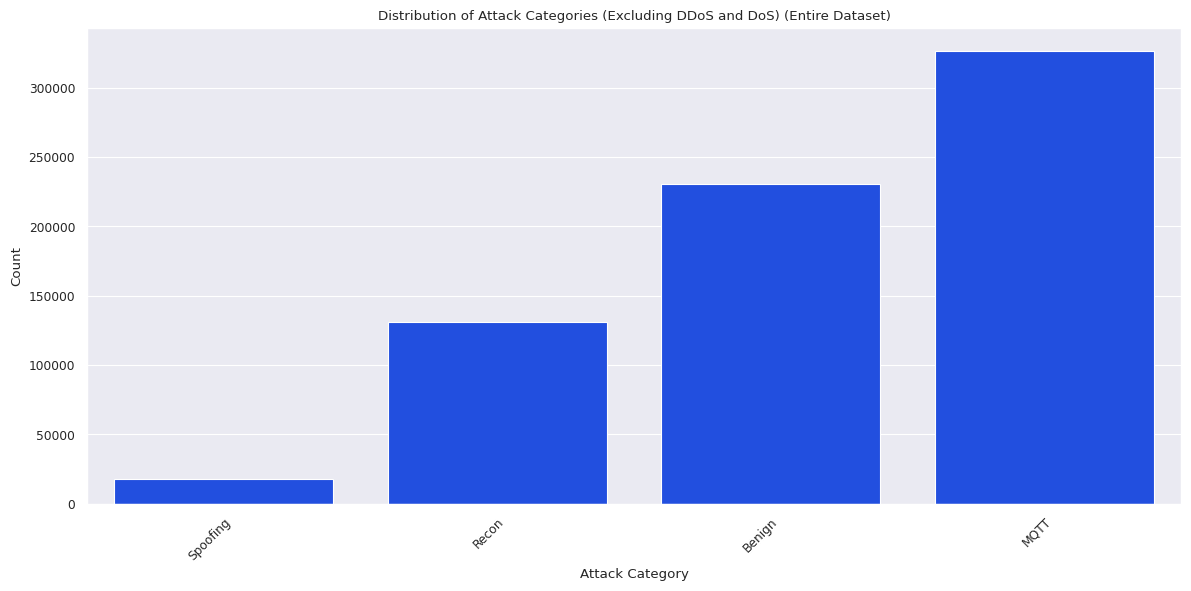

In [39]:
plot_categories_no_ddos_dos(df)

### Attack Categories (All)

In [40]:
def plot_all_attack_categories_bar(data):
    data = data.group_by("Category").len().sort("len", descending=False).to_pandas()
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title("Distribution of Attack Categories (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_558838/3849087223.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


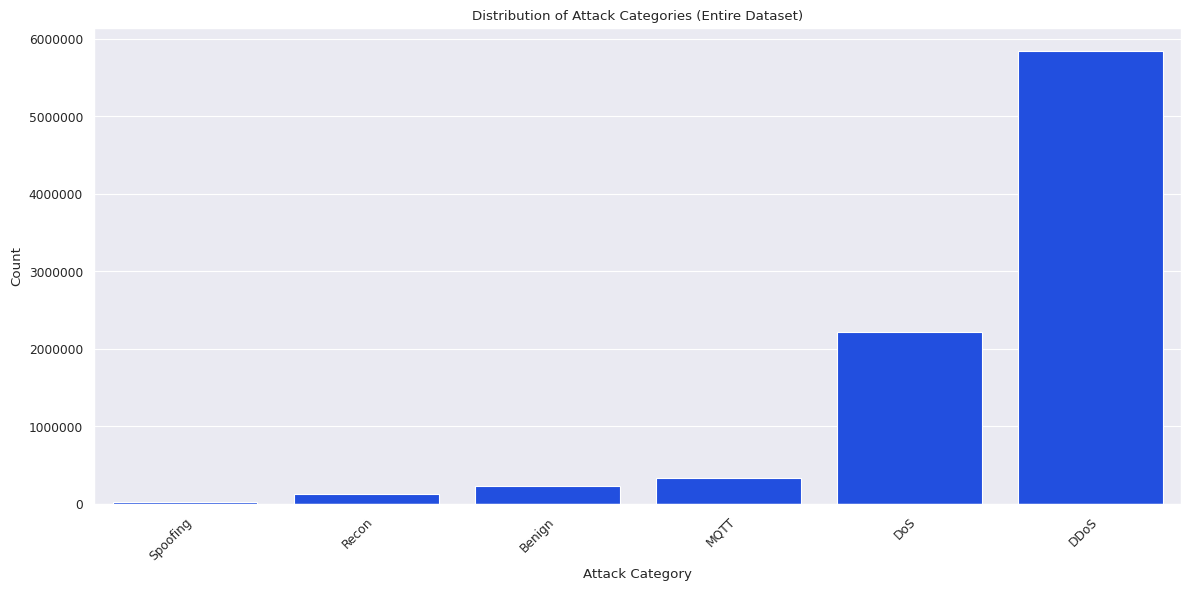

In [41]:
plot_all_attack_categories_bar(df)

### Attack vs Benign Traffic Pie

In [42]:
def plot_attack_benign_pie(data):
    attack_counts = data.group_by("Attack").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = ["Attack", "Count"]

    attack_counts = attack_counts.set_index("Attack")["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    colours = sns.color_palette("hls", len(labels))

    fig, ax = plt.subplots()
    ax.set_title("Comparison between Benign and Attack Data (Entire Dataset)")
    plt.pie(
        slices,
        colors=colours,
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)" for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title="Malicious Traffic?",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

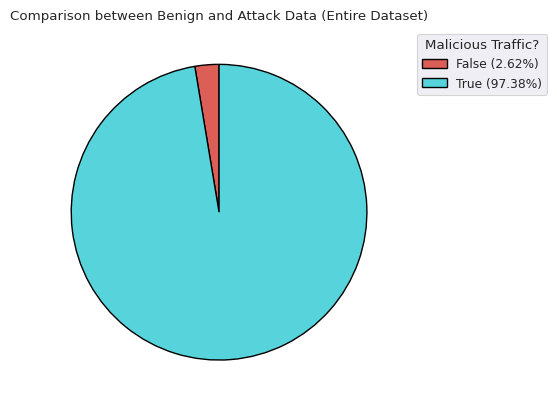

In [43]:
plot_attack_benign_pie(df)

### Correlation Heatmap

In [44]:
def plot_correlation_heatmap(data):
    numeric_data = data.select(
        pl.exclude("Attack", "Category", "Name").name.map(lambda name: name.lower())
    )

    std_devs = numeric_data.select(pl.all().std())
    zer_var_cols = [col for col in std_devs.columns if std_devs[col][0] == 0]
    numeric_data = numeric_data.drop(zer_var_cols)

    corr = numeric_data.corr()
    corr_labels = corr.columns
    corr = corr.to_numpy()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(15, len(corr_labels) // 2))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        square=True,
        ax=ax,
        mask=mask,
        cbar_kws={"label": "Correlation Coefficient", "shrink": 0.5, "aspect": 30},
        xticklabels=corr_labels,
        yticklabels=corr_labels,
    )

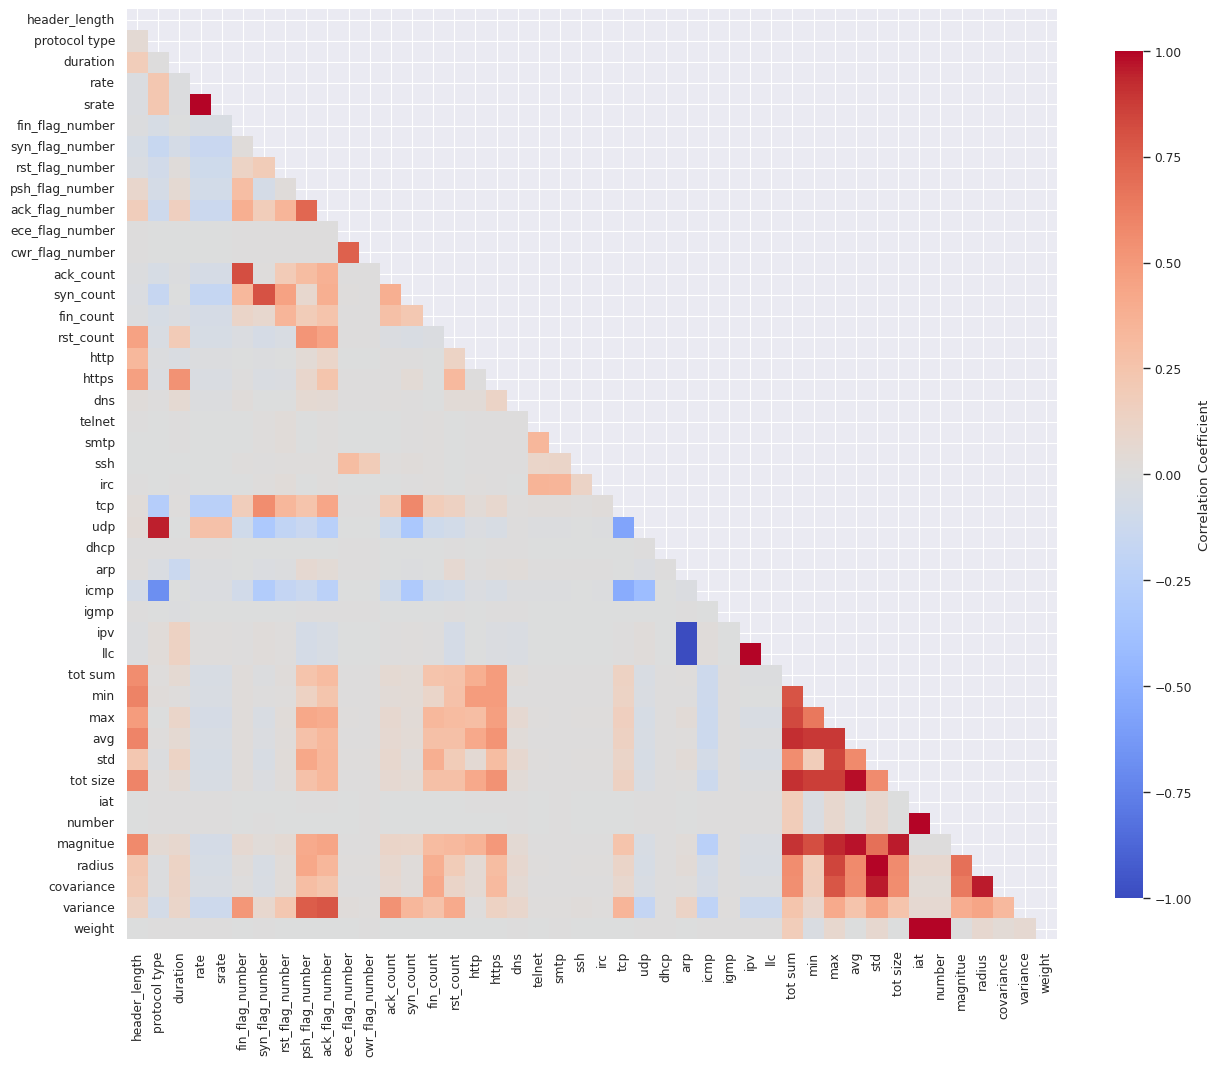

In [45]:
plot_correlation_heatmap(df)